# Inference for Diffusion-Convection-Reaction

# Checking out data attributes

In [48]:
import h5py

file = '/Volumes/T7/PDEFoundry2/DCR/dedalus_v5.1_DiffConvecReac2D_hom_cU1_k1e-03_0.01_seed1.hdf5'

with h5py.File(file, 'r') as f:
    print('ARGS')
    args = f['args']
    print(args.keys())
    for key in args.keys():
        print(f'{key}: {args[key][()]} | {args[key].dtype}')
    print()

    print('COEF')
    coef = f['coef']
    print(coef.keys())

    print('LU')
    for key in coef['Lu'].keys():
        print(f'{key}: {coef["Lu"][key].shape}| {coef["Lu"][key].dtype}')

    print('S')
    for key in coef['s'].keys():
        print(f'{key}: {coef["s"][key].shape}| {coef["s"][key].dtype}')

    for key in ['f0', 'f1', 'f2', 'u_ic']:
        print(key)
        print(f'{coef[key].shape} | {coef[key].dtype}')
    print()

    print('COORD')
    coord = f['coord']
    for key in coord.keys():
        print(f'{key}: {coord[key].shape}')
    print()

    print('PDE INFO')
    info = f['pde_info']
    for key in info.keys():
        print(f'{key}: {info[key][()]}')
    print()

    print('SOL')
    sol = f['sol']
    for key in sol.keys():
        print(f'{key}: {sol[key].shape}')

    print()
    print(f['coef']['Lu']['value'][0])
    print(f['coef']['Lu']['diff_type'][0])
    print(f['coef']['f0'][0])
    print(f['coef']['f1'][0])
    print(f['coef']['f2'][0])

ARGS
<KeysViewHDF5 ['coef_magnitude', 'inhom_diff_u', 'kappa_max', 'kappa_min', 'np_seed', 'num_pde', 'num_sinusoid', 'num_sol_per_npy', 'plot_results', 'print_coef_level', 'u_bound']>
coef_magnitude: 1.0 | float64
inhom_diff_u: False | bool
kappa_max: 0.01 | float64
kappa_min: 0.001 | float64
np_seed: 1 | int64
num_pde: 1000 | int64
num_sinusoid: 0 | int64
num_sol_per_npy: 20 | int64
plot_results: False | bool
print_coef_level: 0 | int64
u_bound: 10 | int64

COEF
<KeysViewHDF5 ['Lu', 'f0', 'f1', 'f2', 's', 'u_ic']>
LU
diff_type: (1000,)| int64
value: (1000,)| float64
S
coef_type: (1000,)| int64
field: (1000, 128, 128)| float64
f0
(1000, 1, 4) | float64
f1
(1000, 1, 4) | float64
f2
(1000, 1, 4) | float64
u_ic
(1000, 128, 128) | float64

COORD
t: (101,)
x: (128, 1)
y: (1, 128)

PDE INFO
is_inverse: False
pde_type_id: 6
preprocess_dag: True
version: 5.1

SOL
u: (1000, 101, 128, 128)

0.006823468619827463
2
[[ 0.        -0.3763371  0.         0.       ]]
[[0. 1. 1. 1.]]
[[ 0.         -0.7

# Load model

In [1]:
#LOAD MODEL
import numpy as np
import matplotlib.pyplot as plt
from mindspore import context
from src import load_config, get_model, PDENodesCollector, sample_grf
from src.inference import infer_plot_2d, x_fenc, y_fenc, interp_fenc

# basic setting
context.set_context(mode=context.GRAPH_MODE, device_target="CPU")
config = load_config("configs/inference/model-M.yaml")
model = get_model(config)

[WARNING] ME(21946:8286985856,MainProcess):2026-06-29-16:08:17.123.000 [mindspore/context.py:1334] For 'context.set_context', the parameter 'device_target' will be deprecated and removed in a future version. Please use the api mindspore.set_device() instead.


# Load pde_type and generate DAG

After u_node: [('uf0', 'uf')]
After pde.set_ic: [('uf0', 'uf'), ('ic1', 'ic', 'uf0')]
After c_or_c2: [('uf0', 'uf'), ('ic1', 'ic', 'uf0'), ('coef2', 'coef')]


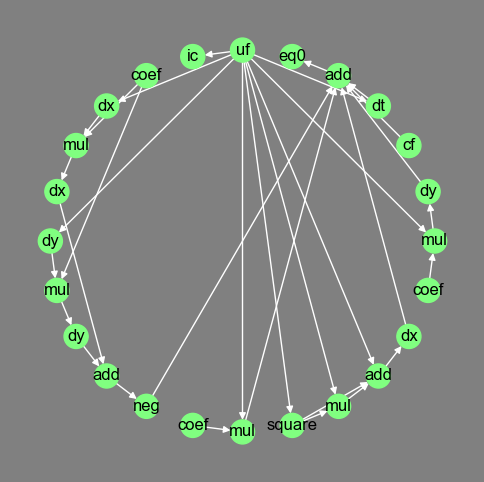

Total num of samples: 1


In [8]:
import h5py
from src.data.multi_pde.pde_types import get_pde_info_cls

raw_data_path = '/Volumes/T7/PDEFoundry2/DCR/dedalus_v5.1_DiffConvecReac2D_hom_cU1_k1e-03_0.01_seed1.hdf5'

pde_type = get_pde_info_cls('dcr')
idx_test = [0]
# idx_test = list(range(0, 10))
pde_dags_list = []

with h5py.File(raw_data_path, 'r') as f:
    for idx in idx_test:
        pde = pde_type.pde_nodes(f, idx, keep_all_coef=False)
        pde_dag = pde.gen_dag(config)
        pde_dag.plot(hide='aux')
        pde_dags_list.append(pde_dag)

print(f'Total num of samples: {len(pde_dags_list)}')

# Inference and plotting

[WARNING] ANALYZER(21946,0x1edf15e80,Python):2026-06-29-16:21:11.907.926 [mindspore/ccsrc/frontend/jit/ps/static_analysis/auto_monad.cc:1608] ClearIsolatedNodes] Some side effect nodes were eliminated by mistake. The node is:@14175_src_cell_pdeformer_pdeformer_PDEEncoder_construct_767:_{[0]: ValueNode<FuncGraph> 16736__tuple_getitem_by_number_768, [1]: ValueNode<ValueTuple> (1, 6, 16384, 5), [2]: ValueNode<Int64Imm> 3}
[WARNING] ANALYZER(21946,0x1edf15e80,Python):2026-06-29-16:21:11.908.759 [mindspore/ccsrc/frontend/jit/ps/static_analysis/auto_monad.cc:1608] ClearIsolatedNodes] Some side effect nodes were eliminated by mistake. The node is:@16869_src_cell_pdeformer_function_encoder_Conv2dFuncEncoderV3_construct_769:_{[0]: ValueNode<FuncGraph> 17029__tuple_getitem_by_number_770, [1]: ValueNode<ValueTuple> (6, 16384, 5), [2]: ValueNode<Int64Imm> 1}
[WARNING] ANALYZER(21946,0x1edf15e80,Python):2026-06-29-16:21:11.909.741 [mindspore/ccsrc/frontend/jit/ps/static_analysis/auto_monad.cc:1601]

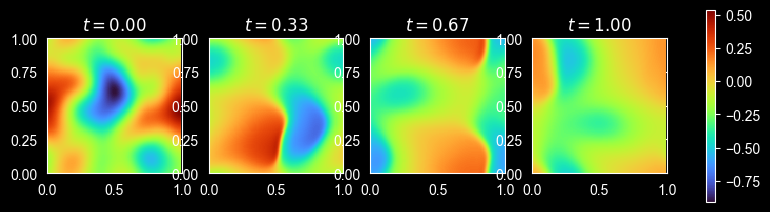

Simulation: 0
(4, 128, 128, 1)


In [9]:
#Set grid space to 128x128, and set to predict 4 time points [0,0.33,0.67,1.00].
#Number of time points predicted can be adjusted.
x_plot, y_plot = np.meshgrid(np.linspace(0, 1, 129)[:-1], np.linspace(0, 1, 129)[:-1], indexing="ij")
snap_t=np.linspace(0, 1, 4)
# pred = infer_plot_2d(model, pde_dag, x_plot, y_plot, snap_t=snap_t)

for i, dag_idx in enumerate(pde_dags_list):
    pred = infer_plot_2d(model, dag_idx, x_plot, y_plot, snap_t=snap_t)
    print('Simulation:', i)
    print(pred.shape)

# Custom plotting code
This block contains code used to plot the ground truth, pred, and absolute error for a single component in a single plot.

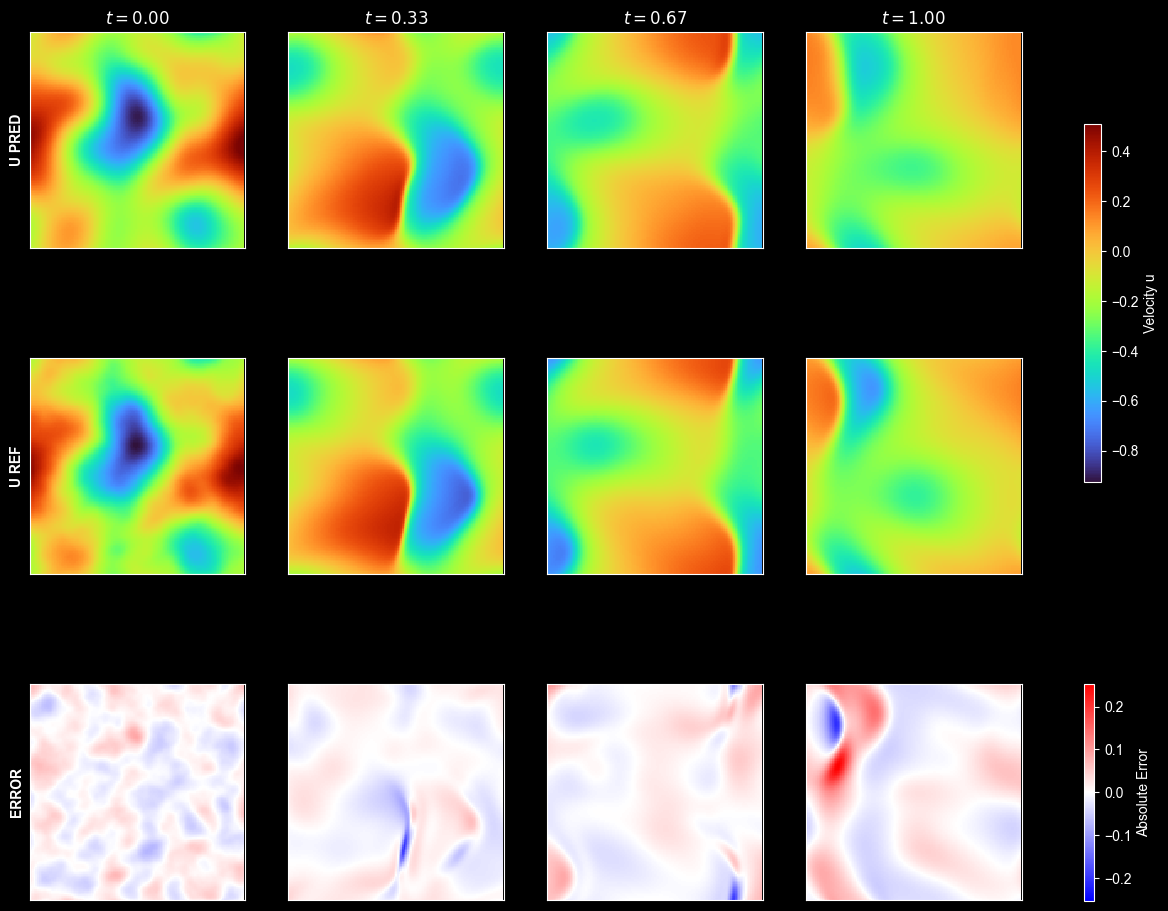

In [12]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

with h5py.File(raw_data_path, "r") as f:
    x_raw = f['coord/x'][:].flatten()
    y_raw = f['coord/y'][:].flatten()
    t_raw = f['coord/t'][:].flatten()
    x_ext, y_ext = np.meshgrid(x_raw, y_raw, indexing="ij")

    u_raw_full = f['sol/u'][0]

t_times = [0, 0.33, 0.67, 1.00]
t_int = [int(t * (len(t_raw) - 1)) for t in t_times]
n_t = len(t_int)

pred_snap = pred[..., 0]   # (4, 128, 128)
ref_snap = u_raw_full[t_int] # (4, 128, 128)

vmin, vmax = ref_snap.min(), ref_snap.max()
vmax_err = np.abs(pred_snap - ref_snap).max()

size_unit = 4
fig, axes = plt.subplots(3, n_t, squeeze=False,
                         figsize=(n_t * size_unit, 3 * size_unit))

for col in range(n_t):
    t_val = t_raw[t_int[col]]

    # Row 0: Pred
    im_p = axes[0, col].pcolormesh(x_ext, y_ext, pred_snap[col],
                                   cmap='turbo', vmin=vmin, vmax=vmax)

    axes[0, col].set_title(f"$t={t_val:.2f}$")

    # Row 1: Ref
    im_r = axes[1, col].pcolormesh(x_ext, y_ext, ref_snap[col],
                                   cmap='turbo', vmin=vmin, vmax=vmax)

    # Row 2: Error
    err = pred_snap[col] - ref_snap[col]
    im_e = axes[2, col].pcolormesh(x_ext, y_ext, err,
                                   cmap='bwr', vmin=-vmax_err, vmax=vmax_err)

    for row in range(3):
        axes[row, col].set_xlim(0, 1)
        axes[row, col].set_ylim(0, 1)
        axes[row, col].set_aspect(1)
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

#Colorbar for Pred and Ref
fig.colorbar(im_r, ax=axes[0:2, :], location='right', shrink=0.6, label='Velocity u')

# Colorbar for Error row
fig.colorbar(im_e, ax=axes[2, :], location='right', shrink=0.8, label='Absolute Error')

# Labels
axes[0, 0].set_ylabel("U PRED", fontweight='bold')
axes[1, 0].set_ylabel("U REF", fontweight='bold')
axes[2, 0].set_ylabel("ERROR", fontweight='bold')

plt.show()

# L2 error calculation
I use calculate_l2_error that is provided in PDEFormer's own codebase.

Unlike the prediction above, where only 4 timesteps are predicted, we now predict all timesteps of our data, without plotting.

Only 1 simulation is used here, but this code block can also be used for multiple simulations

In [5]:
#COMPUTING L2 ERROR for 1 simulation, 101 timesteps each
from src.inference import inference_pde
from src.core.metric import calculate_l2_error
from mindspore import Tensor
import h5py

raw_data_path = '/Volumes/T7/PDEFoundry2/DCR/dedalus_v5.1_DiffConvecReac2D_hom_cU1_k1e-03_0.01_seed1.hdf5'
idx_test = [0]
errors_list = []

with h5py.File(raw_data_path, 'r') as f:
    t_all = f['coord/t'][:].flatten()
    x_raw = f['coord/x'][:].flatten()
    y_raw = f['coord/y'][:].flatten()
    x_grid, y_grid = np.meshgrid(x_raw, y_raw, indexing="ij")

    num_t = len(t_all) # 101

    for sim_idx, dag in enumerate(pde_dags_list):
        print('Simulation:', sim_idx)

        #Reference/Ground truth
        ref_all = np.stack([
            f['sol/u'][sim_idx][:],
        ], axis=-1)

        preds_list = []

        for i in range(num_t):
            # Shape (1, 128, 128, 4), format (t, x, y, z), as per inference_pde code input
            t_step = t_all[i]
            coord_step = np.stack(np.broadcast_arrays(
                t_step, x_grid, y_grid, 0
            ), axis=-1)[None, ...]

            # Inference without plots
            pred_step = inference_pde(model, dag, coord_step)
            preds_list.append(pred_step)

        pred_all = np.concatenate(preds_list, axis=0)
        print(pred_all.shape)

        # Error derivation
        rel_l2_trajectory = calculate_l2_error(Tensor(pred_all), Tensor(ref_all))
        print(f"Mean Rel L2 (Simulation {sim_idx}): {np.mean(rel_l2_trajectory):.6f}")

        errors_list.append(rel_l2_trajectory)

errors_list = np.array(errors_list)

print('Results:')
print('Shape:', errors_list.shape)
print("Overall mean Rel L2:", np.mean(errors_list))

Simulation: 0


[WARNING] ANALYZER(21946,0x1edf15e80,Python):2026-06-29-16:15:27.392.019 [mindspore/ccsrc/frontend/jit/ps/static_analysis/auto_monad.cc:1608] ClearIsolatedNodes] Some side effect nodes were eliminated by mistake. The node is:@8048_src_cell_pdeformer_pdeformer_PDEEncoder_construct_425:_{[0]: ValueNode<FuncGraph> 10609__tuple_getitem_by_number_426, [1]: ValueNode<ValueTuple> (1, 6, 16384, 5), [2]: ValueNode<Int64Imm> 3}
[WARNING] ANALYZER(21946,0x1edf15e80,Python):2026-06-29-16:15:27.392.182 [mindspore/ccsrc/frontend/jit/ps/static_analysis/auto_monad.cc:1608] ClearIsolatedNodes] Some side effect nodes were eliminated by mistake. The node is:@10742_src_cell_pdeformer_function_encoder_Conv2dFuncEncoderV3_construct_427:_{[0]: ValueNode<FuncGraph> 10902__tuple_getitem_by_number_428, [1]: ValueNode<ValueTuple> (6, 16384, 5), [2]: ValueNode<Int64Imm> 1}
[WARNING] ANALYZER(21946,0x1edf15e80,Python):2026-06-29-16:15:27.393.154 [mindspore/ccsrc/frontend/jit/ps/static_analysis/auto_monad.cc:1601] 

(101, 128, 128, 1)
Mean Rel L2 (Simulation 0): 0.098224
Results:
Shape: (1, 101)
Overall mean Rel L2: 0.09822443
